In [1]:
!pip install clustering-benchmarks -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 18.7 MB/s eta 0:00:00


In [2]:
import clustbench
data_url = "https://github.com/gagolews/clustering-data-v1/raw/v1.1.0"

In [3]:
battery_datasets_dict = {
                         'fcps': ['atom', 'chainlink', 'engytime', 'hepta', 'lsun', 'target', 'tetra', 'twodiamonds', 'wingnut'],
                         'g2mg': ['g2mg_4_10', 'g2mg_4_20', 'g2mg_4_30', 'g2mg_4_40', 'g2mg_4_50', 'g2mg_4_60', 'g2mg_4_70', 'g2mg_4_80', 'g2mg_4_90', 'g2mg_8_10', 'g2mg_8_20', 'g2mg_8_30', 'g2mg_8_40', 'g2mg_8_50', 'g2mg_8_60', 'g2mg_8_70', 'g2mg_8_80', 'g2mg_8_90', 'g2mg_16_10', 'g2mg_16_20', 'g2mg_16_30', 'g2mg_16_40', 'g2mg_16_50', 'g2mg_16_60', 'g2mg_16_70', 'g2mg_16_80', 'g2mg_16_90', 'g2mg_32_10', 'g2mg_32_20', 'g2mg_32_30', 'g2mg_32_40', 'g2mg_32_50', 'g2mg_32_60', 'g2mg_32_70', 'g2mg_32_80', 'g2mg_32_90', 'g2mg_64_10', 'g2mg_64_20', 'g2mg_64_30', 'g2mg_64_40', 'g2mg_64_50', 'g2mg_64_60', 'g2mg_64_70', 'g2mg_64_80', 'g2mg_64_90', 'g2mg_128_10', 'g2mg_128_20', 'g2mg_128_30', 'g2mg_128_40', 'g2mg_128_50', 'g2mg_128_60', 'g2mg_128_70', 'g2mg_128_80', 'g2mg_128_90'],
                         'h2mg': ['h2mg_4_10', 'h2mg_4_20', 'h2mg_4_30', 'h2mg_4_40', 'h2mg_4_50', 'h2mg_4_60', 'h2mg_4_70', 'h2mg_4_80', 'h2mg_4_90', 'h2mg_8_10', 'h2mg_8_20', 'h2mg_8_30', 'h2mg_8_40', 'h2mg_8_50', 'h2mg_8_60', 'h2mg_8_70', 'h2mg_8_80', 'h2mg_8_90', 'h2mg_16_10', 'h2mg_16_20', 'h2mg_16_30', 'h2mg_16_40', 'h2mg_16_50', 'h2mg_16_60', 'h2mg_16_70', 'h2mg_16_80', 'h2mg_16_90', 'h2mg_32_10', 'h2mg_32_20', 'h2mg_32_30', 'h2mg_32_40', 'h2mg_32_50', 'h2mg_32_60', 'h2mg_32_70', 'h2mg_32_80', 'h2mg_32_90', 'h2mg_64_10', 'h2mg_64_20', 'h2mg_64_30', 'h2mg_64_40', 'h2mg_64_50', 'h2mg_64_60', 'h2mg_64_70', 'h2mg_64_80', 'h2mg_64_90', 'h2mg_128_10', 'h2mg_128_20', 'h2mg_128_30', 'h2mg_128_40', 'h2mg_128_50', 'h2mg_128_60', 'h2mg_128_70', 'h2mg_128_80', 'h2mg_128_90'],
                         }

## Function get_scores

Get the NCA score of a specific dataset using genie mst algorithm

In [4]:
import genieclust
import sklearn.cluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def get_scores(battery, dataset, apply_scale=False, algo="kmeans"):
  b = clustbench.load_dataset(battery, dataset, url=data_url)

  X_transformed = b.data
  if apply_scale:
    # Scale the data
    #scaler = StandardScaler()
    #X_transformed = scaler.fit_transform(X_transformed)
    X_transformed = clustbench.preprocess_data(X_transformed, random_state=42)

  if algo == "kmeans":
    m = sklearn.cluster.KMeans(n_clusters=b.n_clusters[0])
  elif algo == "birch":
    m = sklearn.cluster.Birch(n_clusters=b.n_clusters[0])
  elif algo == "spectral":
    m = sklearn.cluster.SpectralClustering(n_clusters=b.n_clusters[0], affinity='rbf', random_state=42)
  elif algo == "aglomerative":
    m = sklearn.cluster.AgglomerativeClustering(n_clusters=b.n_clusters[0])
  elif algo == "genie":
    m = genieclust.Genie(n_clusters=b.n_clusters[0])

  results = clustbench.fit_predict_many(m, X_transformed, b.n_clusters[0])
  scores = clustbench.get_score(b.labels[0], results)

  return scores

## Execute get_scores on all datasets as baseline

In [5]:
CLUSTERING_ALGOS = ["kmeans","birch","genie","spectral","aglomerative"]

In [8]:
import tqdm
import pandas as pd
scores_lists = {'Battery':[], 'Dataset':[]}

for battery in tqdm.tqdm(battery_datasets_dict.keys(), desc="Processing Datasets"):
  for dataset in battery_datasets_dict[battery]:
    scores_lists['Battery'].append(battery)
    scores_lists['Dataset'].append(dataset)
    for algo in CLUSTERING_ALGOS:
      CLUSTERING_ALGO = algo
      if f'{CLUSTERING_ALGO} NCA Score' not in scores_lists.keys():
        scores_lists[f'{CLUSTERING_ALGO} NCA Score'] = []
      scores_lists[f'{CLUSTERING_ALGO} NCA Score'].append(get_scores(battery, dataset, algo=algo))

df_baseline = pd.DataFrame.from_dict(scores_lists)

Processing Datasets:  33%|███▎      | 1/3 [00:27<00:55, 27.92s/it]/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited at iteration 697 with accuracies 
[9.11728870e-16 3.30673574e-05 2.97960891e-05]
not reaching the requested tolerance 3.0517578125e-05.
Use iteration 689 instead with accuracy 
1.9997252750165803e-05.

  _, diffusion_map = lobpcg(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited postprocessing with accuracies 
[1.12151162e-15 2.87366114e-05 3.12551468e-05]
not reaching the requested tolerance 3.0517578125e-05.
  _, diffusion_map = lobpcg(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited at iteration 548 with accuracies 
[4.98691527e-16 4.17800835e-05 2.75526442e-05]
not reaching the requested tolerance 3.0517578125e-05.
Use iteration 529 instead with accuracy 
1.8770037838205193e-05.

  _, diffusion_map = lo

In [9]:
df_baseline.style.apply(lambda row:['']*len(row), axis=1)

,Battery,Dataset,kmeans NCA Score,birch NCA Score,genie NCA Score,spectral NCA Score,aglomerative NCA Score
0,fcps,atom,0.440000,0.680000,1.000000,1.000000,0.315000
1,fcps,chainlink,0.318000,0.564000,1.000000,0.502000,0.530000
2,fcps,engytime,0.902832,0.613281,0.901367,0.919922,0.847656
3,fcps,hepta,1.000000,1.000000,1.000000,1.000000,1.000000
4,fcps,lsun,0.705000,0.820000,1.000000,0.837500,0.637500
5,fcps,target,0.840771,0.861708,0.734177,0.882094,0.825895
6,fcps,tetra,1.000000,0.973333,1.000000,1.000000,0.983333
7,fcps,twodiamonds,1.000000,1.000000,0.987500,1.000000,1.000000
8,fcps,wingnut,0.927165,0.836614,1.000000,0.866142,0.775591
9,g2mg,g2mg_4_10,1.000000,1.000000,1.000000,1.000000,1.000000


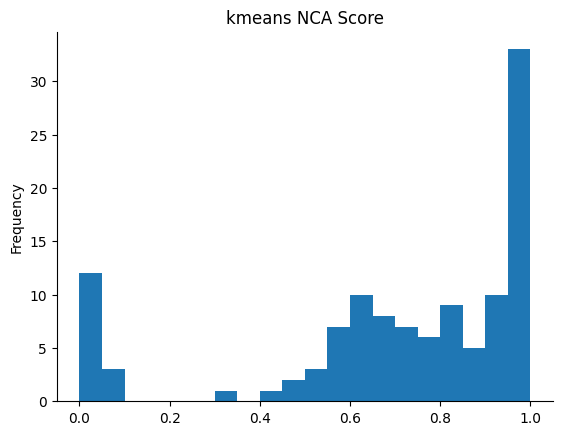

In [ ]:
from matplotlib import pyplot as plt
df_baseline[f'{CLUSTERING_ALGO} NCA Score'].plot(kind='hist', bins=20, title=f'{CLUSTERING_ALGO} NCA Score')
plt.gca().spines[['top', 'right',]].set_visible(False)

# Final Results

In [ ]:
for embs in n_embeddings_list:
  df[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} {embs} NCA Score (Difference)'] = df[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} {embs} NCA Score'] - df[f'{CLUSTERING_ALGO} NCA Score']

def highlight_scores(row):
    color = 'yellow'
    if row[f'{CLUSTERING_ALGO} NCA Score'] < 0.8 and \
     (row[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} 2 NCA Score'] > 0.95 or
      row[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} 4 NCA Score'] > 0.95 or
      row[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} 8 NCA Score'] > 0.95 or
      row[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} 16 NCA Score'] > 0.95 or
      row[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} 32 NCA Score'] > 0.95 or
      row[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} 64 NCA Score'] > 0.95):
        return [f'background-color: {color}'] * len(row)
    return [''] * len(row)

df.style.apply(highlight_scores, axis=1)